# CostGrow Example

Run `fdsc` CostGrow on `tests/data/bryantTechnicalNoteResolution2024` and plot inputs/outputs with consistent raster panels.

## 1) Imports and Paths

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import xarray as xr
import rioxarray
import rasterio
import matplotlib
import matplotlib.pyplot as plt

from fdsc.main import downscale_wse_raster


In [2]:

REPO_DIR = Path.cwd().resolve()
if not (REPO_DIR / 'tests').exists() and (REPO_DIR.parent / 'tests').exists():
    REPO_DIR = REPO_DIR.parent

BASE_DIR = REPO_DIR / 'tests' / 'data' / 'bryantTechnicalNoteResolution2024'
OUT_DIR = REPO_DIR / 'misc' / '_outputs' / 'example'
RUN_DIR = OUT_DIR / 'run_costgrow'
RUN_DIR.mkdir(parents=True, exist_ok=True)

INPUT_DEM_FINE_FP = BASE_DIR / 'dem_04m.tif'
INPUT_WSE_COARSE_FP = BASE_DIR / 'wse_32m.tif'
REFERENCE_WSE_FINE_FP = BASE_DIR / 'wse_04m.tif'
OUTPUT_WSE_FINE_FP = RUN_DIR / 'wse_downscaled_CostGrow.tif'

DISPLAY_SHAPE = (450, 900)

print(f"REPO_DIR:\n    {REPO_DIR}")
print(f"BASE_DIR:\n    {BASE_DIR}")
print(f"RUN_DIR:\n    {RUN_DIR}")
print(f'dem exists: {INPUT_DEM_FINE_FP.exists()}')
print(f'wse coarse exists: {INPUT_WSE_COARSE_FP.exists()}')
print(f'wse reference exists: {REFERENCE_WSE_FINE_FP.exists()}')


REPO_DIR:
    /workspace
BASE_DIR:
    /workspace/tests/data/bryantTechnicalNoteResolution2024
RUN_DIR:
    /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow
dem exists: True
wse coarse exists: True
wse reference exists: True


## 2) Version and File Diagnostics

In [3]:
print(f'python: {sys.version.split()[0]}')
print(f'numpy: {np.__version__}')
print(f'xarray: {xr.__version__}')
print(f'rioxarray: {rioxarray.__version__}')
print(f'rasterio: {rasterio.__version__}')
print(f'matplotlib: {matplotlib.__version__}')

def file_stats(fp: Path):
    st = fp.stat()
    with rasterio.open(fp) as ds:
        return {
            'file': fp.name,
            'size_mb': round(st.st_size / (1024**2), 3),
            'shape': (ds.height, ds.width),
            'crs': str(ds.crs),
            'res': ds.res,
            'nodata': ds.nodata,
            'bounds': tuple(round(v, 3) for v in ds.bounds),
            'dtype': ds.dtypes[0],
        }

stats_l = [
    file_stats(INPUT_DEM_FINE_FP),
    file_stats(INPUT_WSE_COARSE_FP),
    file_stats(REFERENCE_WSE_FINE_FP),
]
print('input file stats:')
for d in stats_l:
    print(f"  {d['file']}: size_mb={d['size_mb']}, shape={d['shape']}, crs={d['crs']}, res={d['res']}, nodata={d['nodata']}, dtype={d['dtype']}")
print('raw file stats dicts:')
for d in stats_l:
    print(d)


python: 3.12.12
numpy: 2.4.2
xarray: 2025.11.0
rioxarray: 0.21.0
rasterio: 1.5.0
matplotlib: 3.10.8
input file stats:
  dem_04m.tif: size_mb=10.596, shape=(1664, 3360), crs=EPSG:4647, res=(4.0, 4.0), nodata=-9999.0, dtype=float32
  wse_32m.tif: size_mb=0.051, shape=(208, 420), crs=EPSG:4647, res=(32.0, 32.0), nodata=-9999.0, dtype=float32
  wse_04m.tif: size_mb=2.164, shape=(1664, 3360), crs=EPSG:4647, res=(4.0, 4.0), nodata=-9999.0, dtype=float32
raw file stats dicts:
{'file': 'dem_04m.tif', 'size_mb': 10.596, 'shape': (1664, 3360), 'crs': 'EPSG:4647', 'res': (4.0, 4.0), 'nodata': -9999.0, 'bounds': (32357390.0, 5596180.0, 32370830.0, 5602836.0), 'dtype': 'float32'}
{'file': 'wse_32m.tif', 'size_mb': 0.051, 'shape': (208, 420), 'crs': 'EPSG:4647', 'res': (32.0, 32.0), 'nodata': -9999.0, 'bounds': (32357390.0, 5596180.0, 32370830.0, 5602836.0), 'dtype': 'float32'}
{'file': 'wse_04m.tif', 'size_mb': 2.164, 'shape': (1664, 3360), 'crs': 'EPSG:4647', 'res': (4.0, 4.0), 'nodata': -9999.0, 

## 3) Load Input Rasters

In [4]:
def load_da(fp: Path, nodata=-9999.0) -> xr.DataArray:
    da = rioxarray.open_rasterio(fp, masked=False).squeeze().compute().rio.write_nodata(nodata)
    return da.where(da != nodata, np.nan)

dem_fine_xr = load_da(INPUT_DEM_FINE_FP)
wse_coarse_xr = load_da(INPUT_WSE_COARSE_FP)
wse_reference_xr = load_da(REFERENCE_WSE_FINE_FP)

print(f'dem_fine_xr shape={dem_fine_xr.shape}, res={dem_fine_xr.rio.resolution()}, crs={dem_fine_xr.rio.crs}')
print(f'wse_coarse_xr shape={wse_coarse_xr.shape}, res={wse_coarse_xr.rio.resolution()}, crs={wse_coarse_xr.rio.crs}')
print(f'wse_reference_xr shape={wse_reference_xr.shape}, res={wse_reference_xr.rio.resolution()}, crs={wse_reference_xr.rio.crs}')

print(f'dem wet count: {int(dem_fine_xr.notnull().sum())}')
print(f'coarse wse wet count: {int(wse_coarse_xr.notnull().sum())}')
print(f'reference wse wet count: {int(wse_reference_xr.notnull().sum())}')

dem_fine_xr shape=(1664, 3360), res=(4.0, -4.0), crs=EPSG:4647
wse_coarse_xr shape=(208, 420), res=(32.0, -32.0), crs=EPSG:4647
wse_reference_xr shape=(1664, 3360), res=(4.0, -4.0), crs=EPSG:4647
dem wet count: 5591040
coarse wse wet count: 6907
reference wse wet count: 473710


## 4) Plot Setup and Helpers (inline, lightweight)

In [5]:
cm = 1 / 2.54

plt.style.use('default')
for k, v in {
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.titlesize': 12,
    'figure.figsize': (16 * cm, 10 * cm),
    'font.family': 'serif',
}.items():
    matplotlib.rcParams[k] = v

print(f'loaded matplotlib {matplotlib.__version__}')

def nn_resample_2d(arr: np.ndarray, target_shape=DISPLAY_SHAPE) -> np.ndarray:
    assert arr.ndim == 2
    if arr.shape == target_shape:
        return arr
    yi = np.clip(np.round(np.linspace(0, arr.shape[0] - 1, target_shape[0])).astype(int), 0, arr.shape[0] - 1)
    xi = np.clip(np.round(np.linspace(0, arr.shape[1] - 1, target_shape[1])).astype(int), 0, arr.shape[1] - 1)
    return arr[np.ix_(yi, xi)]

def plot_raster(ax, da: xr.DataArray, title: str, cmap='viridis', vmin=None, vmax=None, target_shape=DISPLAY_SHAPE):
    arr = da.data.astype(float)
    arr_disp = nn_resample_2d(arr, target_shape=target_shape)

    bounds = da.rio.bounds()
    im = ax.imshow(
        arr_disp,
        extent=(bounds[0], bounds[2], bounds[1], bounds[3]),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation='nearest',
        origin='upper',
        aspect='equal',
    )

    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    raw_res = da.rio.resolution()
    ax.text(
        0.02,
        0.02,
        f'raw shape: {da.shape}\nraw res: ({raw_res[0]:.6f}, {raw_res[1]:.6f})',
        transform=ax.transAxes,
        fontsize=8,
        ha='left',
        va='bottom',
        bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none'},
    )
    return im


loaded matplotlib 3.10.8


## 5) Plot Inputs

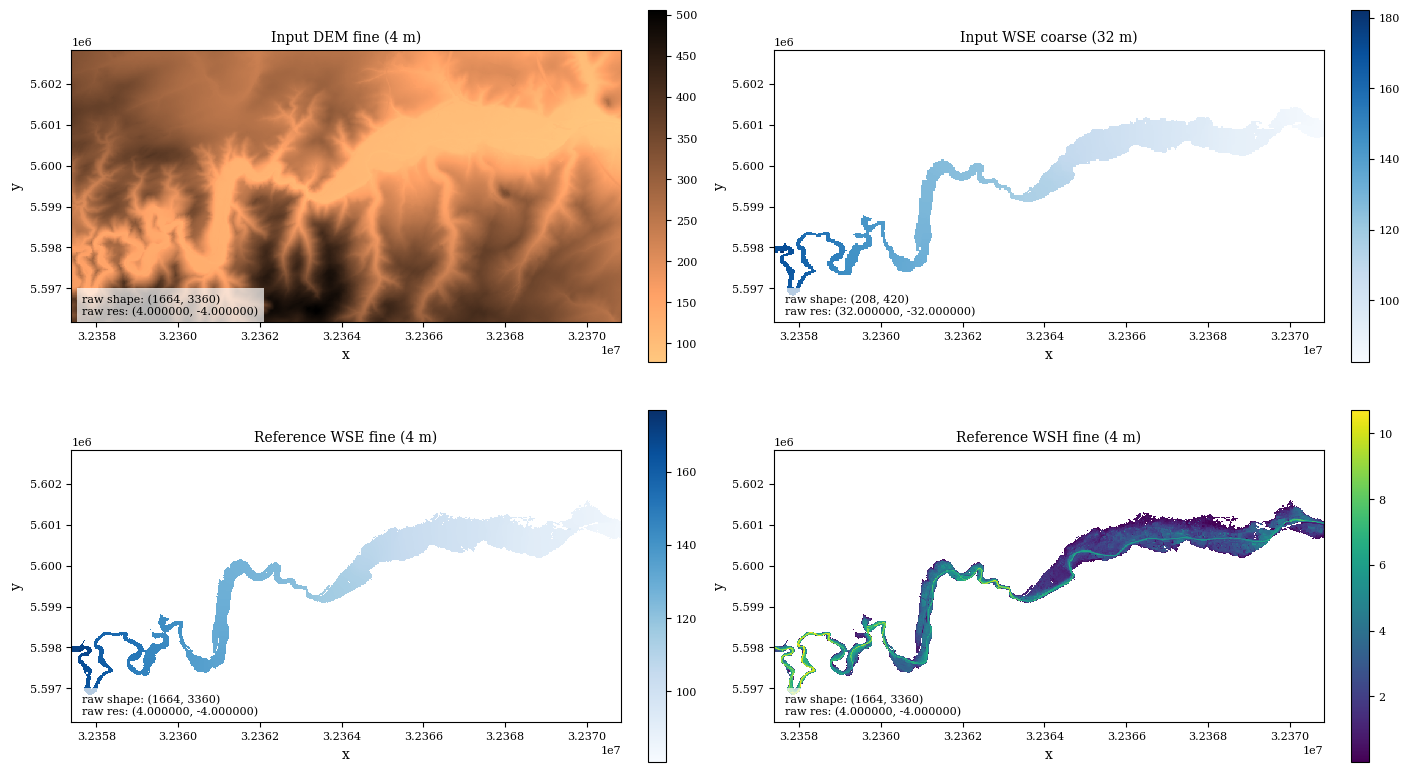

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

im0 = plot_raster(axes[0, 0], dem_fine_xr, 'Input DEM fine (4 m)', cmap='copper_r')
fig.colorbar(im0, ax=axes[0, 0], shrink=0.9)

im1 = plot_raster(axes[0, 1], wse_coarse_xr, 'Input WSE coarse (32 m)', cmap='Blues')
fig.colorbar(im1, ax=axes[0, 1], shrink=0.9)

im2 = plot_raster(axes[1, 0], wse_reference_xr, 'Reference WSE fine (4 m)', cmap='Blues')
fig.colorbar(im2, ax=axes[1, 0], shrink=0.9)

wsh_reference_xr = xr.where(wse_reference_xr.notnull(), wse_reference_xr - dem_fine_xr, np.nan)
im3 = plot_raster(axes[1, 1], wsh_reference_xr, 'Reference WSH fine (4 m)', cmap='viridis')
fig.colorbar(im3, ax=axes[1, 1], shrink=0.9)

plt.show()

## 6) Run CostGrow

In [7]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')
logger = logging.getLogger('example_notebook')

ofp, meta_d = downscale_wse_raster(
    str(INPUT_DEM_FINE_FP),
    str(INPUT_WSE_COARSE_FP),
    method='CostGrow',
    pluvial=False,
    out_dir=str(RUN_DIR),
    logger=logger,
)

print('downscale finished')
print(f"output file:\n    {ofp}")
print(f'meta entries: {len(meta_d)}')
print('meta sample:')
for k in sorted(meta_d.keys())[:20]:
    print(f'  {k}: {meta_d[k]}')


2026-02-22 12:22:11,088 INFO example_notebook: enahcing resolution from (208, 420) to (1664, 3360)
/opt/conda/envs/dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-22 12:22:11,216 INFO example_notebook.costGrow: passed all checks and downscale=8
    {'00_inputs_wse_coarse': '/workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/00_inputs_wse_coarse_0208x0420.tif', '00_inputs_dem_fine': '/workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/00_inputs_dem_fine_1664x3360.tif', 'downscale': 8, 'fine_shape': (1664, 3360), 'coarse_shape': (208, 420), 'start': datetime.datetime(2026, 2, 22, 12, 22, 11, 215309), 'dem_mask_cnt': np.int64(0), 'wse_coarse_wet_cnt': np.int64(6907), 'debug': True}
2026-02-22 12:22:11,217 INFO example_notebook.costGrow: 01_resamp
2026-02-22 12:22:

downscale finished
output file:
    /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/wse_downscaled_CostGrow.tif
meta entries: 24
meta sample:
  00_inputs_dem_fine: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/00_inputs_dem_fine_1664x3360.tif
  00_inputs_wse_coarse: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/00_inputs_wse_coarse_0208x0420.tif
  01_resamp_wse_fine: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/01_resamp_wse_fine_1664x3360.tif
  02_wp_wse_fine: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/02_wp_wse_fine_1664x3360.tif
  03_dp_00linear_decay_0.001000_fp: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/decay/03_dp_00linear_decay_0.001000_1664x3360.tif
  03_dp_0distance: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgrow/03_dp_0distance_1664x3360.tif
  03_dp_1grow_thresh: /workspace/_outputs/bryantTechnicalNoteResolution2024/run_costgr

## 7) Output Diagnostics

In [8]:
output_fp = Path(ofp)
assert output_fp.exists(), output_fp

wse_downscaled_xr = load_da(output_fp)
wsh_downscaled_xr = xr.where(wse_downscaled_xr.notnull(), wse_downscaled_xr - dem_fine_xr, np.nan)
diff_xr = wse_downscaled_xr - wse_reference_xr

with rasterio.open(output_fp) as ds:
    print(f'output size MB: {output_fp.stat().st_size/(1024**2):,.3f}')
    print(f'output shape: {(ds.height, ds.width)}')
    print(f'output crs: {ds.crs}')
    print(f'output res: {ds.res}')
    print(f'output nodata: {ds.nodata}')
    print(f'output bounds: {tuple(round(v, 3) for v in ds.bounds)}')

print(f'output wet count: {int(wse_downscaled_xr.notnull().sum())}')
print(f'reference wet count: {int(wse_reference_xr.notnull().sum())}')
print(f'diff mean: {float(diff_xr.mean(skipna=True)):.6f}')
print(f'diff std: {float(diff_xr.std(skipna=True)):.6f}')

output size MB: 3.107
output shape: (1664, 3360)
output crs: EPSG:4647
output res: (4.0, 4.0)
output nodata: -9999.0
output bounds: (32357390.0, 5596180.0, 32370830.0, 5602836.0)
output wet count: 446688
reference wet count: 473710
diff mean: -0.268981
diff std: 0.625070


## 8) Plot Output and Comparison

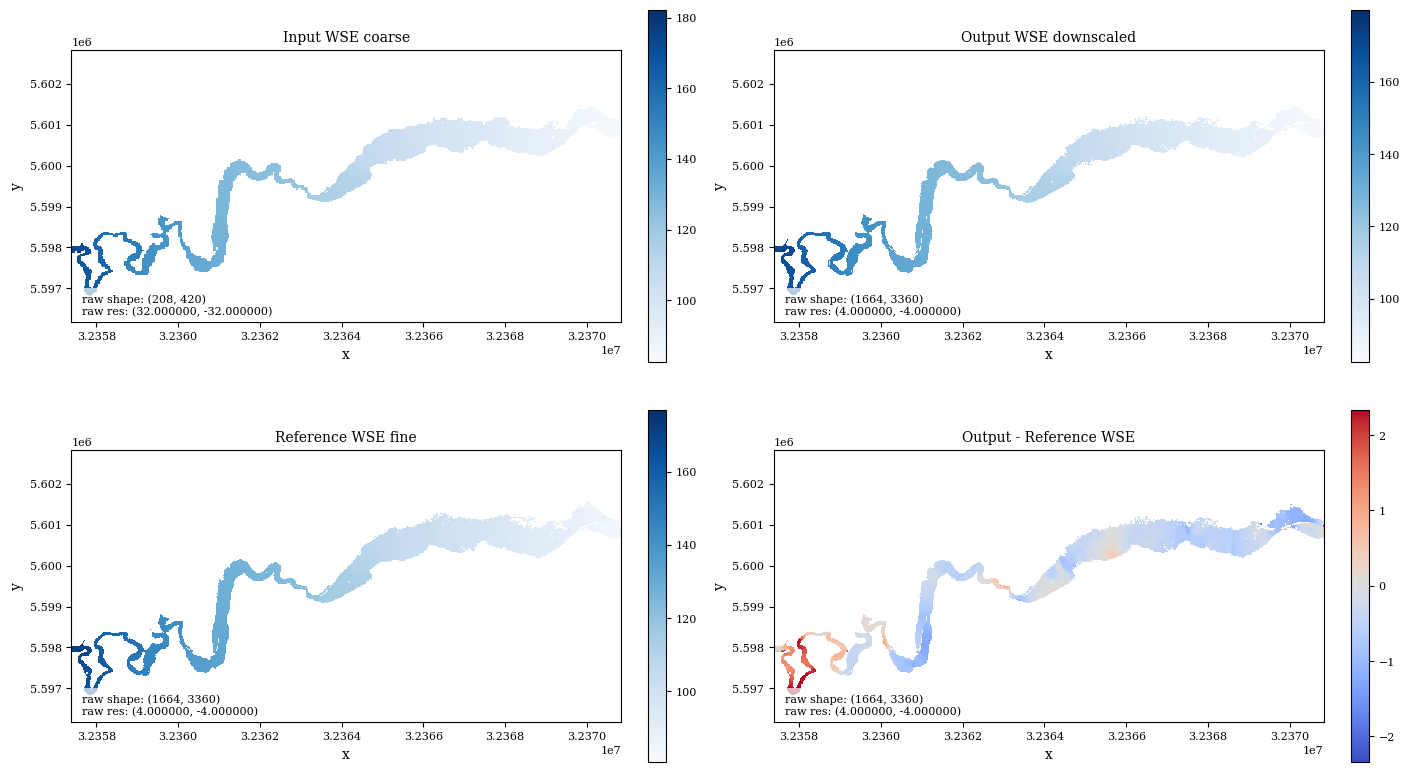

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

im0 = plot_raster(axes[0, 0], wse_coarse_xr, 'Input WSE coarse', cmap='Blues')
fig.colorbar(im0, ax=axes[0, 0], shrink=0.9)

im1 = plot_raster(axes[0, 1], wse_downscaled_xr, 'Output WSE downscaled', cmap='Blues')
fig.colorbar(im1, ax=axes[0, 1], shrink=0.9)

im2 = plot_raster(axes[1, 0], wse_reference_xr, 'Reference WSE fine', cmap='Blues')
fig.colorbar(im2, ax=axes[1, 0], shrink=0.9)

vmax = float(np.nanpercentile(np.abs(diff_xr.data), 99))
im3 = plot_raster(axes[1, 1], diff_xr, 'Output - Reference WSE', cmap='coolwarm', vmin=-vmax, vmax=vmax)
fig.colorbar(im3, ax=axes[1, 1], shrink=0.9)

plt.show()

## 9) Artifacts

- Output WSE: `misc/example_outputs/run_costgrow/wse_downscaled_CostGrow.tif`
- Additional debug rasters/logs are in `misc/example_outputs/run_costgrow/`